# Task 8: Dynamical Decoupling

这个 notebook 现在按下面的流程运行：

1. 先在命令行单独运行 `python calibrate.py`，分别定标 `x` 和 `sx`。
2. notebook 读取 `calibration_results.json`，把定标结果写回脉冲配置。
3. 在三能级 transmon + DRAG 脉冲 + MCWF 多轨迹下，对比 `fid / hahn / cpmg / xy4 / xy8 / udd` 的抗慢频漂能力。

这里重点看两件事：

- `P1(t)`：不同 DD 序列对相干保持的效果。
- `P2(t)` 和末态 `P2`：三能级模型下的泄漏是否变明显。


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np

from musiq.workflow import create_model

MODEL_DIR = Path.cwd()
CIRC_DIR = MODEL_DIR / 'circuits'
FIG_DIR = MODEL_DIR / 'figures'
CALIBRATION_PATH = MODEL_DIR / 'calibration_results.json'
FIG_DIR.mkdir(exist_ok=True)

SEQUENCES = ['fid', 'hahn', 'cpmg', 'xy4', 'xy8', 'udd']
NTRAJ = 12

print(f'MODEL_DIR = {MODEL_DIR}')
print(f'mcwf_ntraj = {NTRAJ}')


MODEL_DIR = d:\GitHub\MuSIQ\report\task8_dynamical_decoupling
mcwf_ntraj = 12


## 1. 读取单独定标结果

如果这里报 `FileNotFoundError`，先在 `report/task8_dynamical_decoupling/` 目录运行一次：

```bash
python calibrate.py
```


In [2]:
%run calibrate.py

Optimization terminated successfully.
         Current function value: 0.000000
         Iterations: 96
         Function evaluations: 229
Optimization terminated successfully.
         Current function value: 0.000000
         Iterations: 95
         Function evaluations: 239
best x  amplitude_Hz = 26644953.8  drag_beta = 0.1163  terminal population = {'0': 2.0029370432640498e-07, '1': 0.9999820384473892, '2': 1.776125890633924e-05}
best sx amplitude_Hz = 13268881.3 drag_beta = 0.1194 terminal population = {'0': 0.49999863597942845, '1': 0.4999993128417691, '2': 2.0511788023513924e-06}


In [3]:
if not CALIBRATION_PATH.exists():
    raise FileNotFoundError(
        f'Missing {CALIBRATION_PATH.name}. Run `python calibrate.py` in {MODEL_DIR} first.'
    )

calibration = json.loads(CALIBRATION_PATH.read_text(encoding='utf-8'))
x_amp = float(calibration['x']['amplitude_Hz'])
x_beta = float(calibration['x']['drag_beta'])
sx_amp = float(calibration['sx']['amplitude_Hz'])
sx_beta = float(calibration['sx']['drag_beta'])

print(f'calibrated x  amplitude_Hz = {x_amp:.1f}')
print(f'calibrated x  drag_beta = {x_beta:.4f}')
print(f'calibrated sx amplitude_Hz = {sx_amp:.1f}')
print(f'calibrated sx drag_beta = {sx_beta:.4f}')
print('x terminal populations :', calibration['x'].get('terminal_population', {}))
print('sx terminal populations:', calibration['sx'].get('terminal_population', {}))


calibrated x  amplitude_Hz = 26644953.8
calibrated x  drag_beta = 0.1163
calibrated sx amplitude_Hz = 13268881.3
calibrated sx drag_beta = 0.1194
x terminal populations : {'0': 2.0029370432640498e-07, '1': 0.9999820384473892, '2': 1.776125890633924e-05}
sx terminal populations: {'0': 0.49999863597942845, '1': 0.4999993128417691, '2': 2.0511788023513924e-06}


## 2. 批量运行 DD 序列

这里统一使用：

- 三能级求解配置 `simulation_level: nlevel`
- `drag` 形状的 `x / sx / y` 脉冲
- `mcwf_ntraj = 12`，避免只看单条 trajectory


In [4]:
model = create_model(
    circuits={c: CIRC_DIR / f'{c}.yaml' for c in SEQUENCES},
    devices=MODEL_DIR / 'device.yaml',
    pulses=MODEL_DIR / 'pulses.yaml',
    solvers=MODEL_DIR / 'solver.yaml',
    analysers=MODEL_DIR / 'analyser.yaml',
)

model.config.solvers['solver_0'].run.mcwf_ntraj = 100
gates = model.config.pulses['default'].extras['gates']
gates['x']['amplitude_Hz']   = x_amp
gates['x']['drag_beta']      = x_beta
gates['sx']['amplitude_Hz']  = sx_amp
gates['sx']['drag_beta']     = sx_beta

model.run_all()

MCWF shots [########################] 100/100
MCWF shots [########################] 100/100
MCWF shots [########################] 100/100
MCWF shots [########################] 100/100
MCWF shots [########################] 100/100
MCWF shots [########################] 100/100


In [5]:
def extract_results(model) -> dict[str, dict[str, np.ndarray | float]]:
    results = {}

    for run_name, run_obj in model.runs.items():
        analysis = model.find_analysis_for_run(run_name)
        if analysis is None:
            continue

        pop_metric = analysis.output.metrics["population_mean"]
        times_us = np.asarray(pop_metric.times, dtype=float) * 1e6
        p0 = np.asarray(pop_metric.values.get("0", []), dtype=float)
        p1 = np.asarray(pop_metric.values.get("1", []), dtype=float)
        p2 = np.asarray(pop_metric.values.get("2", np.zeros_like(p1)), dtype=float)

        results[run_name] = {
            "times_us": times_us,
            "p0": p0,
            "p1": p1,
            "p2": p2,
            "final_p0": float(p0[-1]),
            "final_p1": float(p1[-1]),
            "final_p2": float(p2[-1]),
        }

    return results


results = extract_results(model)

for name in SEQUENCES:
    data = results[name]
    print(
        f"{name:>4s} | final P0={data['final_p0']:.4f} | "
        f"final P1={data['final_p1']:.4f} | final P2={data['final_p2']:.4f}"
    )


 fid | final P0=0.3721 | final P1=0.6279 | final P2=0.0000
hahn | final P0=0.2328 | final P1=0.7671 | final P2=0.0000
cpmg | final P0=0.0915 | final P1=0.9084 | final P2=0.0001
 xy4 | final P0=0.1558 | final P1=0.8442 | final P2=0.0001
 xy8 | final P0=0.0970 | final P1=0.9028 | final P2=0.0002
 udd | final P0=0.1181 | final P1=0.8819 | final P2=0.0000


## 3. 作图与排序

上图看 `P1(t)`，下图同时比较末态 `P1` 和 `P2`，方便区分“相干保持更好”与“泄漏更严重”这两类情况。


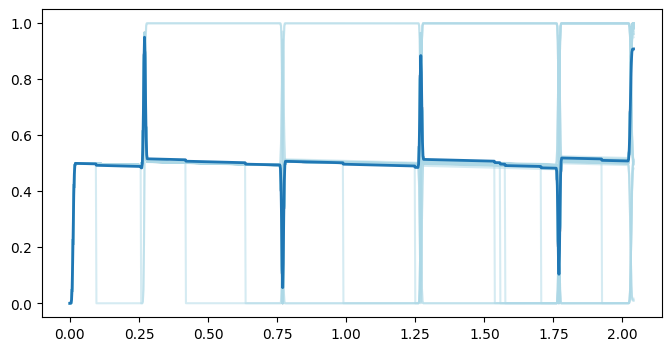

In [6]:
from random import random, randint

circ_name = 'cpmg'
fig, ax = plt.subplots(figsize=(8, 4))
for i in range(100):
    shot = model.runs[circ_name].results['param_0'].trajectories[i]
    ax.plot(np.asarray(shot.times) * 1e6, np.abs(np.asarray(shot.wave_function)[:,1])**2, color="lightblue", alpha=0.5)

ax.plot(results[circ_name]['times_us'], results[circ_name]['p1'], linewidth=2.0, label=name.upper())
    # ax.plot(shot.times, np.abs(np.asarray(shot.density_matrix['snapshots'])[:,0])**2, '--')

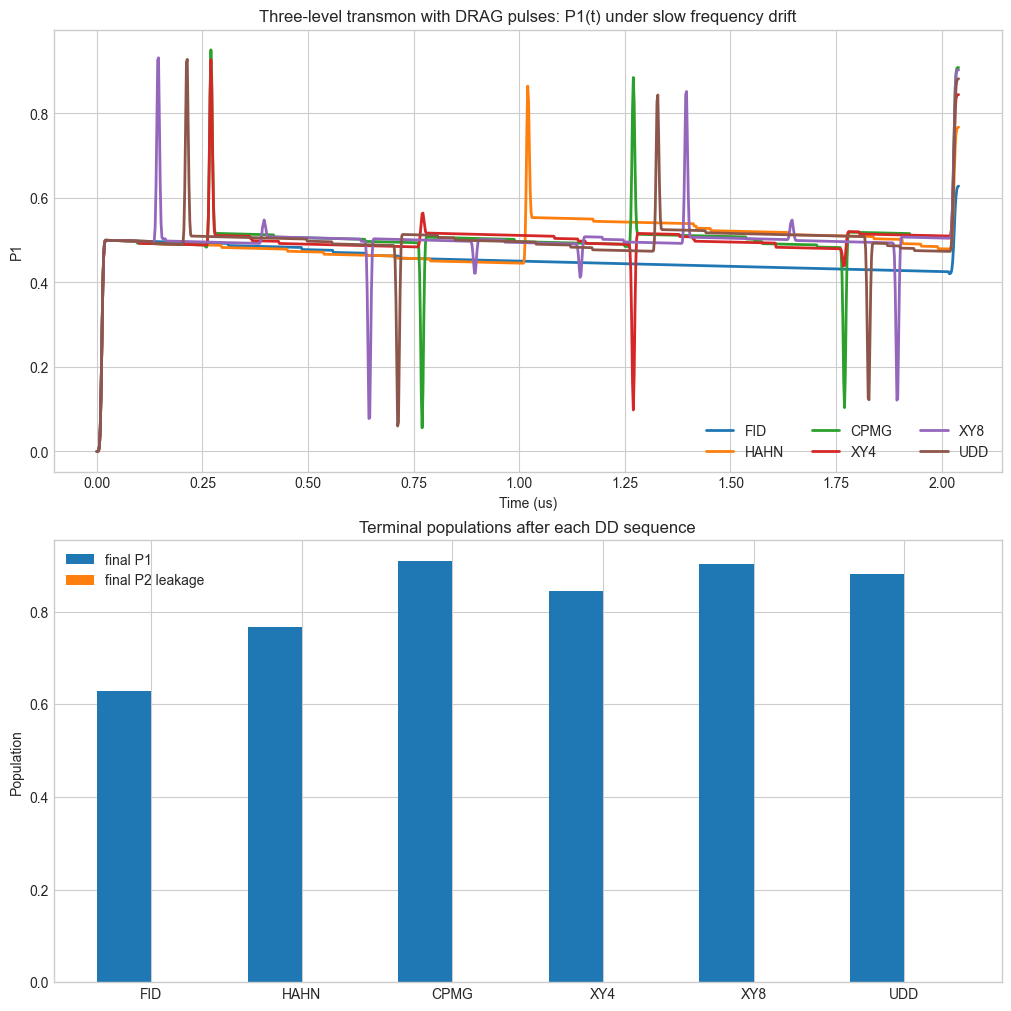

Saved figure to d:\GitHub\MuSIQ\report\task8_dynamical_decoupling\figures\dd_sequence_comparison_3level_drag.png


In [7]:
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(2, 1, figsize=(10, 10), constrained_layout=True)

for name in SEQUENCES:
    axes[0].plot(results[name]['times_us'], results[name]['p1'], linewidth=2.0, label=name.upper())

axes[0].set_title('Three-level transmon with DRAG pulses: P1(t) under slow frequency drift')
axes[0].set_xlabel('Time (us)')
axes[0].set_ylabel('P1')
axes[0].legend(ncol=3)

labels = [name.upper() for name in SEQUENCES]
x = np.arange(len(SEQUENCES), dtype=float)
width = 0.36
final_p1 = [results[name]['final_p1'] for name in SEQUENCES]
final_p2 = [results[name]['final_p2'] for name in SEQUENCES]

axes[1].bar(x - width / 2, final_p1, width=width, label='final P1')
axes[1].bar(x + width / 2, final_p2, width=width, label='final P2 leakage')
axes[1].set_title('Terminal populations after each DD sequence')
axes[1].set_xticks(x, labels)
axes[1].set_ylabel('Population')
axes[1].legend()

figure_path = FIG_DIR / 'dd_sequence_comparison_3level_drag.png'
fig.savefig(figure_path, dpi=180, bbox_inches='tight')
plt.show()

print(f'Saved figure to {figure_path}')


In [8]:
ranking = sorted(
    (
        (name, data['final_p1'], data['final_p2'])
        for name, data in results.items()
    ),
    key=lambda item: (-item[1], item[2]),
)

print('Ranking by higher final P1 and lower final P2:')
for idx, (name, final_p1, final_p2) in enumerate(ranking, start=1):
    print(f'{idx}. {name.upper():<4s} final P1={final_p1:.4f}, final P2={final_p2:.4f}')


Ranking by higher final P1 and lower final P2:
1. CPMG final P1=0.9084, final P2=0.0001
2. XY8  final P1=0.9028, final P2=0.0002
3. UDD  final P1=0.8819, final P2=0.0000
4. XY4  final P1=0.8442, final P2=0.0001
5. HAHN final P1=0.7671, final P2=0.0000
6. FID  final P1=0.6279, final P2=0.0000


Text(0.5, 1.0, 'Task 8 Pulse Waveforms for All Sequences')

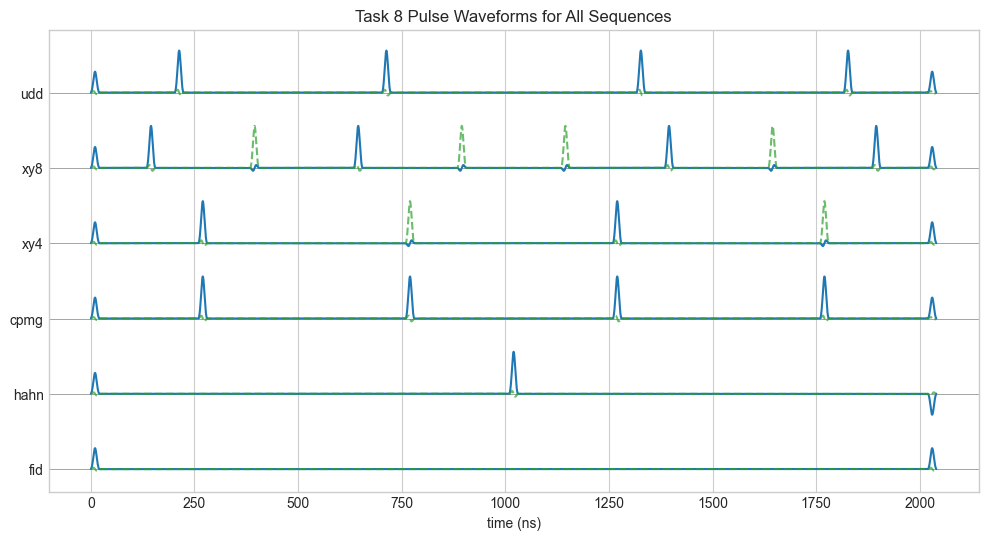

In [9]:
from musiq.pulse.sequence import PulseCompiler

sample_rate_Hz = 5e10
seq_names = SEQUENCES

fig, ax = plt.subplots(figsize=(12, 6))

seq_gap = 4.0
channel_gap = 0.5
amp_scale = 1.5e-8

base = 0.0
yticks = []
yticklabels = []

for seq_name in seq_names:
    pulse_samples = PulseCompiler.compile(
        model.runs[seq_name].artifacts.pulse_ir,
        sample_rate_Hz=sample_rate_Hz,
    )

    for i, (channel, waveform) in enumerate(pulse_samples.items()):
        if channel[:2] == "XY":
            colors = ["tab:blue", "tab:green"]
        elif channel[:2] == "TC":
            colors = ["tab:orange", "tab:gold"]
        else:
            colors = ["tab:red", "tab:pink"]

        row = base + channel_gap * i
        t_ns = np.asarray(waveform["t"], dtype=float) * 1e9

        ax.plot(t_ns, np.asarray(waveform["y"]) * amp_scale + row, color=colors[0], linewidth=1.5)
        if "y_quadrature" in waveform:
            ax.plot(
                t_ns,
                np.asarray(waveform["y_quadrature"]) * amp_scale + row,
                "--",
                color=colors[1],
                linewidth=1.5,
                alpha=0.7,
            )

        yticks.append(row)
        yticklabels.append(f"{seq_name}")

    base += channel_gap * len(pulse_samples) + seq_gap

ax.set_yticks(yticks)
ax.set_yticklabels(yticklabels)
ax.grid(color="gray", linestyle="-", linewidth=0.5, axis="y", zorder=0)
ax.set_xlabel("time (ns)")
ax.set_title("Task 8 Pulse Waveforms for All Sequences")